<a href="https://colab.research.google.com/github/xszc0123/ABCD-A/blob/20250529/yolov8_train_segment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 초기 환경 설정

In [1]:
# YOLOv8 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [2]:
# 필요한 라이브러리 임포트
import os
from ultralytics import YOLO
import shutil
from google.colab import drive
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# 파일 선택기를 통한 업로드/ 학습된 zip 파일을 다운로드 한다.
uploaded = files.upload()

Saving Test.v2i.yolov8.zip to Test.v2i.yolov8.zip


In [4]:
# 코랩 셀에서 ! 를 앞에 붙여서 실행
!mkdir -p /content/dataset
!unzip /content/Test.v2i.yolov8.zip -d /content/dataset

Archive:  /content/Test.v2i.yolov8.zip
  inflating: /content/dataset/README.dataset.txt  
  inflating: /content/dataset/README.roboflow.txt  
  inflating: /content/dataset/data.yaml  
   creating: /content/dataset/train/
   creating: /content/dataset/train/images/
 extracting: /content/dataset/train/images/346-_jpg.rf.bbba26f45ccd774b661ead1f70fdeba5.jpg  
 extracting: /content/dataset/train/images/347-_jpg.rf.197bd1b53b99d6d7d318f91892455ea0.jpg  
 extracting: /content/dataset/train/images/348-_jpg.rf.657cf9c63e1ffde1d160dfacfe0bf64a.jpg  
 extracting: /content/dataset/train/images/349-_jpg.rf.a4a79ca71e6471ec885f3ffeb87b854c.jpg  
 extracting: /content/dataset/train/images/350-_jpg.rf.aab5388644a61fbb334ade32395adbcf.jpg  
 extracting: /content/dataset/train/images/351-_jpg.rf.741338bc04f4ff3bceeb48577a3e5107.jpg  
 extracting: /content/dataset/train/images/352-_jpg.rf.ef9bba7ece6cc0241d87e3d876a7aba6.jpg  
 extracting: /content/dataset/train/images/353-_jpg.rf.e095483a463f18dc2a0c31

다음 폴더 구조를 수정합니다.


content/

├── dataset
│   ├──train
│   │   ├──images
│   │   ├──labels
│   ├──valid
│   │   ├──images
│   ├──test
│   │   ├──images
└── data.yaml





In [5]:
#test/images 폴더 생성
!mkdir -p /content/dataset/test/images
!cp /content/dataset/train/images/* /content/dataset/test/images/

In [6]:
#valid/images 폴더 생성
!mkdir -p /content/dataset/valid/images
!cp /content/dataset/train/images/* /content/dataset/valid/images/

In [7]:
#valid/labels 폴더 생성
!mkdir -p /content/dataset/valid/labels
!cp /content/dataset/train/labels/* /content/dataset/valid/labels/

#data.yaml 파일 수정

train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images

In [8]:
# 학습 시작
from ultralytics import YOLO

# Segmentation 모델로 학습
model = YOLO('yolov8l-seg.pt')  # segmentation 모델 사용

results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolov8_seg_custom',
    project='/content/runs/train',
    patience=10,
    save=True,
    device=0
)

100%|██████████| 88.1M/88.1M [00:01<00:00, 88.2MB/s]


Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_seg_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 18.0MB/s]

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              


  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  3   4461568  ultralytics.nn.modules.block.C2f             [512, 512, 3, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  3   4723712  ultralytics.nn.modules.block.C2f             [1024

...


50 epochs completed in 0.060 hours.
Optimizer stripped from /content/runs/train/yolov8_seg_custom/weights/last.pt, 92.3MB
Optimizer stripped from /content/runs/train/yolov8_seg_custom/weights/best.pt, 92.3MB

Validating /content/runs/train/yolov8_seg_custom/weights/best.pt...
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-seg summary (fused): 125 layers, 45,914,972 parameters, 0 gradients, 220.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]


                   all         15        105       0.96      0.986      0.992      0.818       0.97      0.941      0.967      0.715
           dotted-line         15         60       0.95      0.945      0.982      0.791       0.92      0.765      0.884      0.578
             left_lane         15         15      0.966          1      0.995       0.82      0.989          1      0.995      0.688
             left_line         15         15      0.953          1      0.995      0.794      0.983          1      0.995      0.724
            right_lane         15         15       0.97          1      0.995      0.866       0.99          1      0.995      0.869
Speed: 0.2ms preprocess, 20.5ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/train/yolov8_seg_custom


In [9]:
# 학습된 모델 로드(폴더에 맞도록)
model = YOLO('/content/runs/train/yolov8_seg_custom/weights/best.pt')

# 테스트 실행
results = model.predict(
    source='/content/dataset/test/images',  # 테스트 이미지 경로
    save=True,                              # 결과 저장
    save_txt=True,                          # 텍스트 결과도 저장
    conf=0.5,                               # 신뢰도 임계값
    project='/content/runs/detect',         # 저장 프로젝트 경로
    name='test_results'                     # 폴더 이름 지정
)


image 1/15 /content/dataset/test/images/346-_jpg.rf.bbba26f45ccd774b661ead1f70fdeba5.jpg: 640x640 3 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 66.5ms
image 2/15 /content/dataset/test/images/347-_jpg.rf.197bd1b53b99d6d7d318f91892455ea0.jpg: 640x640 4 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 50.4ms
image 3/15 /content/dataset/test/images/348-_jpg.rf.657cf9c63e1ffde1d160dfacfe0bf64a.jpg: 640x640 3 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 51.5ms
image 4/15 /content/dataset/test/images/349-_jpg.rf.a4a79ca71e6471ec885f3ffeb87b854c.jpg: 640x640 3 dotted-lines, 2 left_lanes, 1 left_line, 1 right_lane, 50.3ms
image 5/15 /content/dataset/test/images/350-_jpg.rf.aab5388644a61fbb334ade32395adbcf.jpg: 640x640 4 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 41.1ms
image 6/15 /content/dataset/test/images/351-_jpg.rf.741338bc04f4ff3bceeb48577a3e5107.jpg: 640x640 5 dotted-lines, 2 left_lanes, 1 left_line, 1 right_lane, 40.3ms
image 7/15 /content/dataset/tes

In [10]:
import cv2

def draw_enhanced_results(image_path, results):
    """세그멘테이션 마스크를 이미지 위에 시각화"""
    # 이미지 로드
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 클래스 색상 정의
    class_names = ['dotted-line', 'left_lane', 'left_line', 'right_lane', 'right_line']
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

    for result in results:
        masks = result.masks  # 마스크 객체

        if masks is not None and masks.data is not None:
            mask_data = masks.data.cpu().numpy()  # (N, H, W)
            cls_list = result.boxes.cls.cpu().numpy().astype(int)  # 클래스 인덱스 리스트
            conf_list = result.boxes.conf.cpu().numpy()  # 신뢰도

            for i in range(len(mask_data)):
                mask = mask_data[i]
                cls_id = cls_list[i]
                conf = conf_list[i]

                # 마스크 색상 및 클래스 이름
                color = colors[cls_id % len(colors)]
                class_name = class_names[cls_id] if cls_id < len(class_names) else f'class_{cls_id}'
                label = f'{class_name}: {conf:.2f}'

                # 마스크를 컬러로 적용
                colored_mask = np.zeros_like(img_rgb, dtype=np.uint8)
                for c in range(3):
                    colored_mask[:, :, c] = mask * color[c]

                # 반투명하게 overlay
                img_rgb = cv2.addWeighted(img_rgb, 1.0, colored_mask, 0.4, 0)

                # 마스크 경계 추출하여 텍스트 위치 추정
                contours, _ = cv2.findContours((mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if contours:
                    x, y, w, h = cv2.boundingRect(contours[0])
                    # 라벨 텍스트
                    (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                    cv2.rectangle(img_rgb, (x, y - text_height - 10), (x + text_width, y), color, -1)
                    cv2.putText(img_rgb, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return img_rgb


Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


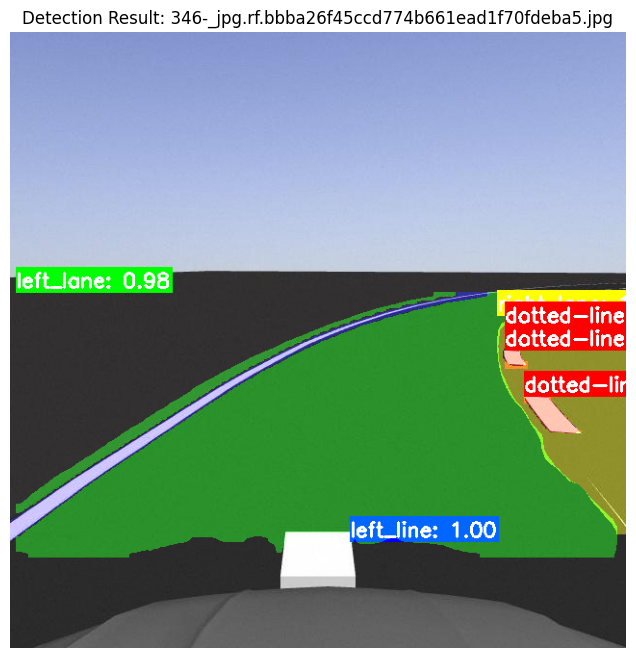

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


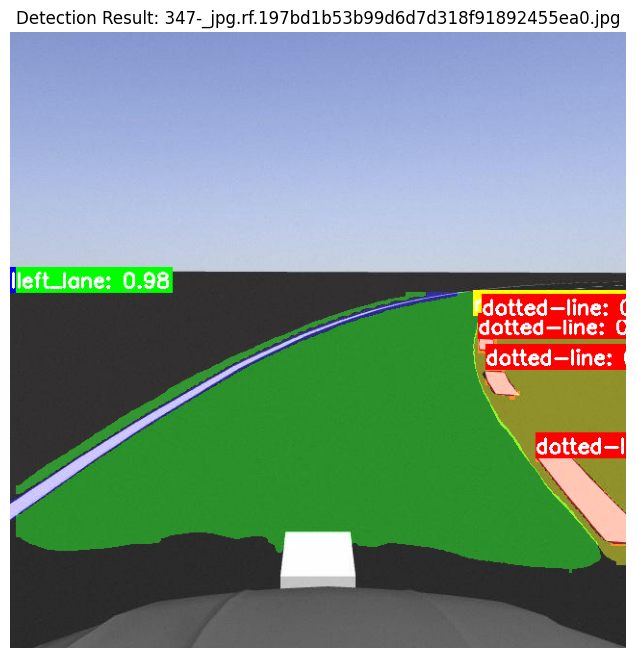

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


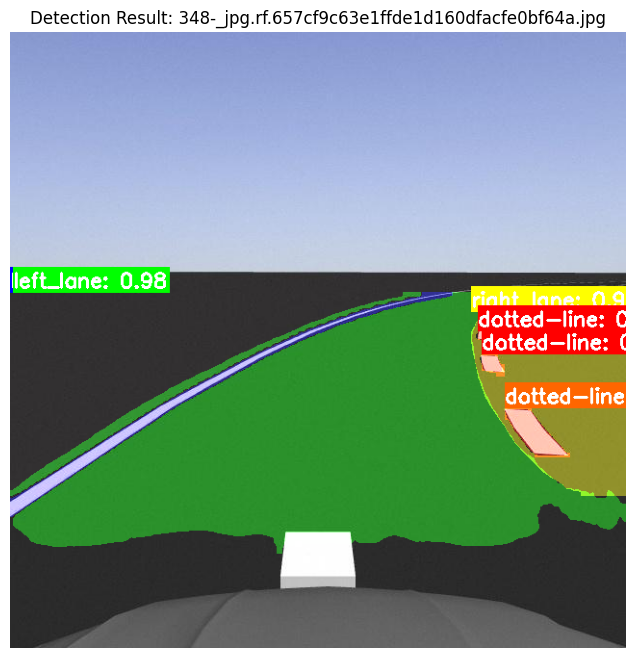

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


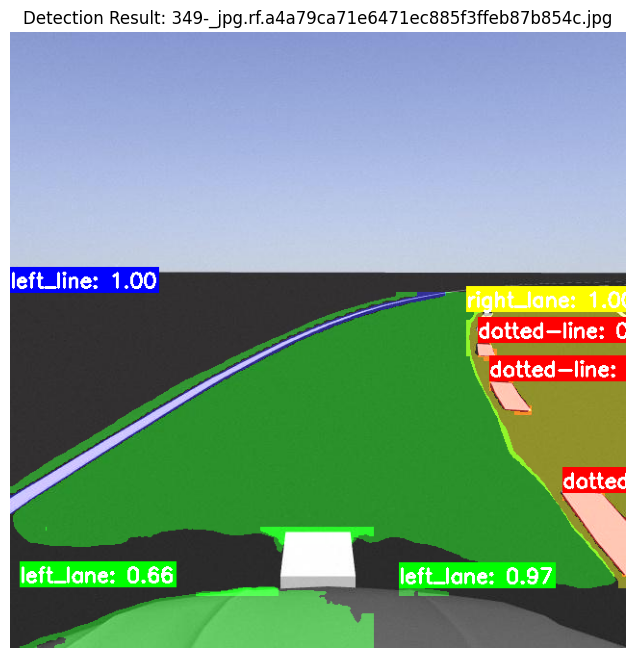

Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels


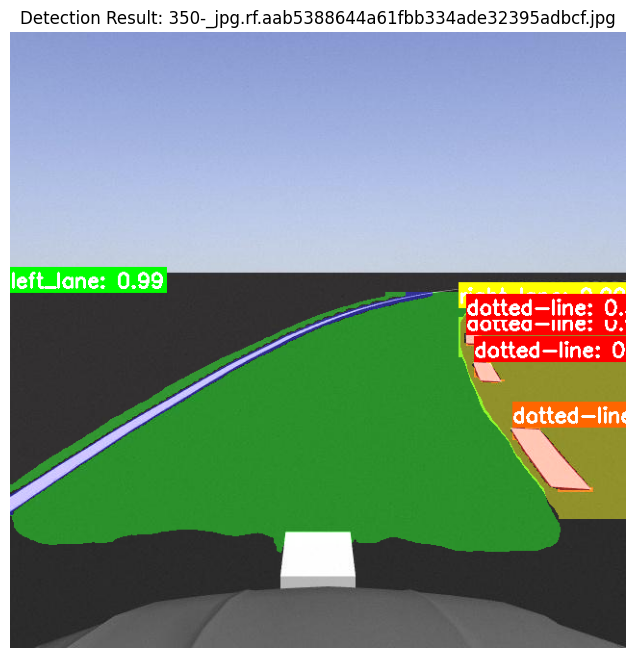

In [11]:
import matplotlib.pyplot as plt
import numpy as np

image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])


for i, img_name in enumerate(test_images[:5]):  # 처음 5개만
    img_path = f'/content/dataset/test/images/{img_name}'

    # 예측 실행
    result = model.predict(img_path, conf=0.5, verbose=False)

    # 향상된 시각화
    enhanced_img = draw_enhanced_results(img_path, result)

    # 결과 표시
    plt.figure(figsize=(12, 8))
    plt.imshow(enhanced_img)
    plt.title(f'Detection Result: {img_name}')
    plt.axis('off')
    plt.show()


In [16]:
import shutil
from google.colab import files

# 1. zip 파일로 압축 (기존 zip 파일이 있다면 덮어씌움)
shutil.make_archive('/content/runs_backup', 'zip', '/content/runs')

# 2. 다운로드 링크 제공
files.download('/content/runs_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import base64

# YOLO 예측 + 시각화 함수 (콜라보용)
image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])

frames = []

# 이미지 처리
num_images = min(len(test_images), 15)  # 15개 이미지 사용

print(f"총 {num_images}개 이미지 처리 시작...")

for i, img_name in enumerate(test_images[:num_images]):
    img_path = os.path.join(image_dir, img_name)

    try:
        # 예측 실행
        result = model.predict(img_path, conf=0.5, verbose=False)

        # 향상된 시각화
        enhanced_img = draw_enhanced_results(img_path, result)

        # PIL Image를 numpy array로 변환
        if hasattr(enhanced_img, 'convert'):
            enhanced_img = enhanced_img.convert('RGB')
            img_array = np.array(enhanced_img)
        else:
            img_array = enhanced_img

        # RGB -> BGR (OpenCV용)
        bgr_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

        # 해상도 통일 (HD 품질)
        bgr_img = cv2.resize(bgr_img, (1280, 720))

        frames.append(bgr_img)
        print(f"✅ 프레임 {i+1}/{num_images} 처리 완료")

    except Exception as e:
        print(f"❌ 이미지 {img_name} 처리 실패: {e}")
        continue

if len(frames) == 0:
    print("❌ 처리된 프레임이 없습니다!")
    exit()

print(f"총 {len(frames)}개 프레임 준비 완료")

# 🎬 7초 동영상을 위한 프레임 확장
target_duration = 7  # 7초
fps = 24  # 안정적인 24 FPS

# 각 프레임을 여러 번 반복하여 7초 채우기
frames_per_image = 4  # 각 이미지를 4프레임 동안 유지
extended_frames = []

for frame in frames:
    for _ in range(frames_per_image):
        extended_frames.append(frame.copy())

# 7초에 맞춰 프레임 수 조정
target_frame_count = target_duration * fps  # 168 프레임

# 프레임 수가 부족하면 반복, 많으면 잘라내기
while len(extended_frames) < target_frame_count:
    extended_frames.extend(frames)  # 원본 프레임들 추가

extended_frames = extended_frames[:target_frame_count]  # 정확히 7초분만 사용

print(f"최종 프레임 수: {len(extended_frames)} (예상 길이: {len(extended_frames)/fps:.1f}초)")

# 🔄 동영상 생성 (여러 방법 시도)
video_path = "/content/detection_results_7sec.mp4"

try:
    # 방법 1: H.264 코덱 시도
    height, width, channels = extended_frames[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    # VideoWriter 생성
    out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

    if not out.isOpened():
        raise Exception("VideoWriter 초기화 실패")

    print("동영상 생성 중...")
    for i, frame in enumerate(extended_frames):
        # 프레임 데이터 타입 확인 및 변환
        if frame.dtype != np.uint8:
            frame = frame.astype(np.uint8)

        success = out.write(frame)
        if not success:
            print(f"⚠️ 프레임 {i} 쓰기 실패")

        if (i + 1) % 30 == 0:
            print(f"진행률: {(i+1)/len(extended_frames)*100:.1f}%")

    out.release()

    # 파일 생성 확인
    if os.path.exists(video_path) and os.path.getsize(video_path) > 0:
        print(f"✅ 동영상 생성 성공: {video_path}")
        print(f"📊 파일 크기: {os.path.getsize(video_path)/1024/1024:.2f} MB")

        # 동영상 정보 확인
        cap = cv2.VideoCapture(video_path)
        if cap.isOpened():
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps_check = cap.get(cv2.CAP_PROP_FPS)
            duration = frame_count / fps_check if fps_check > 0 else 0

            print(f"📹 동영상 정보:")
            print(f"   - 해상도: {width}x{height}")
            print(f"   - FPS: {fps_check}")
            print(f"   - 총 프레임: {frame_count}")
            print(f"   - 길이: {duration:.1f}초")

            cap.release()

        # Colab에서 다운로드
        try:
            from google.colab import files
            files.download(video_path)
            print("🎉 다운로드 링크 생성 완료!")
        except:
            print("⚠️ 다운로드 링크 생성 실패 (수동으로 파일을 다운로드하세요)")

    else:
        raise Exception("동영상 파일 생성 실패")

except Exception as e:
    print(f"❌ 첫 번째 방법 실패: {e}")

    # 방법 2: AVI 형식으로 재시도
    try:
        video_path_avi = "/content/detection_results_7sec.avi"
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(video_path_avi, fourcc, fps, (width, height))

        print("AVI 형식으로 재시도...")
        for frame in extended_frames:
            if frame.dtype != np.uint8:
                frame = frame.astype(np.uint8)
            out.write(frame)

        out.release()

        if os.path.exists(video_path_avi) and os.path.getsize(video_path_avi) > 0:
            print(f"✅ AVI 동영상 생성 성공: {video_path_avi}")

            from google.colab import files
            files.download(video_path_avi)

        else:
            raise Exception("AVI 파일도 생성 실패")

    except Exception as e2:
        print(f"❌ AVI 방법도 실패: {e2}")

        # 방법 3: 개별 이미지로 저장
        print("개별 이미지로 저장합니다...")

        output_dir = "/content/video_frames/"
        os.makedirs(output_dir, exist_ok=True)

        for i, frame in enumerate(extended_frames):
            frame_path = os.path.join(output_dir, f"frame_{i:04d}.jpg")
            cv2.imwrite(frame_path, frame)

        print(f"✅ {len(extended_frames)}개 프레임을 {output_dir}에 저장했습니다.")
        print("이 이미지들을 다운로드하여 외부 도구로 동영상을 만드세요.")

# 시스템 정보 출력
print("\n🔍 시스템 정보:")
print(f"OpenCV 버전: {cv2.__version__}")
print(f"사용 가능한 VideoWriter 백엔드: {[cv2.videoio_registry.getBackendName(b) for b in cv2.videoio_registry.getBackends()]}")

# 간단한 테스트 동영상 생성
print("\n🧪 테스트 동영상 생성...")
test_video_path = "/content/test_video.mp4"
test_frame = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
test_writer = cv2.VideoWriter(test_video_path, fourcc, 10, (640, 480))

if test_writer.isOpened():
    for _ in range(50):  # 5초 테스트
        test_writer.write(test_frame)
    test_writer.release()

    if os.path.exists(test_video_path):
        print("✅ 테스트 동영상 생성 성공 - 시스템은 정상입니다")
    else:
        print("❌ 테스트 동영상 생성 실패 - 시스템 문제 있음")
else:
    print("❌ 테스트 VideoWriter 초기화 실패")

총 15개 이미지 처리 시작...
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels
✅ 프레임 1/15 처리 완료
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels
✅ 프레임 2/15 처리 완료
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels
✅ 프레임 3/15 처리 완료
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels
✅ 프레임 4/15 처리 완료
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels
✅ 프레임 5/15 처리 완료
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels
✅ 프레임 6/15 처리 완료
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/detect/test_results/labels
✅ 프레임 7/15 처리 완료
Results saved to /content/runs/detect/test_results
15 labels saved to /content/runs/d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 다운로드 링크 생성 완료!

🔍 시스템 정보:
OpenCV 버전: 4.11.0
사용 가능한 VideoWriter 백엔드: ['FFMPEG', 'FFMPEG', 'GSTREAMER', 'INTEL_MFX', 'V4L2', 'CV_IMAGES', 'CV_MJPEG', 'UEYE', 'OBSENSOR']

🧪 테스트 동영상 생성...
✅ 테스트 동영상 생성 성공 - 시스템은 정상입니다
